# Chapter 20: Geodesics

Source span inspected: Coxeter, *Introduction to Geometry*, chapter 20, printed pages 366-378 (PDF pages 384-396). The PDF pages are scanned, so I inspected temporary rendered page images for structure, terminology, and formulas. This notebook is original teaching material; it does not reproduce textbook prose, exercises, figures, screenshots, page crops, or layouts.

## Chapter Goal

A geodesic is not just a shortest-looking curve. It is the curve whose acceleration has no tangential component when the surface metric is used. This chapter turns that idea into a computational lesson: Christoffel symbols become an ODE, Gaussian curvature becomes an intrinsic metric invariant, geodesic triangles measure total curvature through their angle excess or defect, and the Euler-Poincare characteristic records the same curvature budget over a closed surface.

The chapter ends by comparing constant-curvature geometries. The sphere, Euclidean plane, and hyperbolic plane share the same geodesic-polar template `ds^2 = dr^2 + f(r)^2 dtheta^2`, but the function `f` changes from `sin r` to `r` to `sinh r`. The pseudosphere then gives a concrete warning: a surface can have constant negative curvature without containing the whole hyperbolic plane.

## Computational Translation Guide

| Source idea | Computational representation | Inspection target | Check |
|---|---|---|---|
| Theorema egregium | compare plane, cylinder, and sphere metrics | embedding can change while `K` stays intrinsic | plane and cylinder first fundamental forms match |
| Geodesic equations | integrate `r'' - f f' theta'^2 = 0`, `(f^2 theta')' = 0` | curves bend in coordinates while speed and angular momentum stay fixed | numerical drift in speed and momentum |
| Integral curvature of a geodesic triangle | angle-budget ledger for spherical and hyperbolic examples | `int K dS = A + B + C - pi` changes sign with curvature | excess/defect identities |
| Euler-Poincare characteristic | polyhedral curvature ledger | total curvature is `2 pi chi` on closed surfaces | `V - E + F` and angle-deficit totals |
| Constant-curvature surfaces | geodesic circle radius function `f(r)` | `sin r`, `r`, and `sinh r` encode `K=1,0,-1` | symbolic `K = -f''/f` |
| Angle of parallelism | Lobachevsky curve `Pi(a) = 2 arctan(exp(-a))` | limiting parallel angle decreases with distance | half-angle and trig identities |
| Pseudosphere | tractrix surface of revolution | meridians act like lines, circles act like horocycles, edge cuts off the model | metric coefficients and `K=-1` |

## Visualization Storyboard

| Section | Artifact | Library route | Why this route |
|---|---|---|---|
| Intrinsic curvature | `theorema-egregium-intrinsic-vs-embedding.html` | Plotly 3D plus SymPy | rotating surfaces makes the embedding/metric distinction inspectable; SymPy checks curvature from `f` |
| Geodesic ODEs | `geodesic-equations-constant-curvature-flow.png` | SciPy ODE plus Matplotlib | ODE integration exposes speed and angular-momentum invariants directly |
| Triangle curvature | `geodesic-triangle-curvature-budget.png` | Matplotlib | a ledger is clearer than a decorative triangle when the theorem is an angle/area balance |
| Euler-Poincare | `euler-poincare-total-curvature-ledger.png` | mesh counts plus Matplotlib | graph counts and angle deficits make topology visible |
| Constant curvature | `constant-curvature-geodesic-circles.png` | SymPy plus Matplotlib | the same radial metric template produces all three curvatures |
| Angle of parallelism | `angle-of-parallelism-lobachevsky.png` | NumPy plus Matplotlib | the formula becomes a monotone function with testable identities |
| Pseudosphere | `pseudosphere-tractrix-negative-curvature.html` | Plotly 3D plus SymPy | the horn-shaped surface and its metric limitations need spatial inspection |

In [1]:
from pathlib import Path
import sys, json, csv, math

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon
import sympy as sp
from scipy.integrate import solve_ivp
from IPython.display import Markdown, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

try:
    import networkx as nx
except Exception:
    nx = None


def find_book_root() -> Path:
    here = Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.append(base)
        candidates.append(base / "Introduction-to-Geometry")
    for candidate in candidates:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate Introduction-to-Geometry book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact

CHAPTER_NO = 20
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-20"
DIRS = {kind: ARTIFACT_ROOT / kind for kind in ["figures", "html", "checks", "tables", "data"]}
for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)
FIG = DIRS["figures"]
HTML = DIRS["html"]
CHECKS = DIRS["checks"]
TABLES = DIRS["tables"]
DATA = DIRS["data"]

for stale in [FIG / "concept_configuration.svg", FIG / "parameter_experiment.svg", CHECKS / "visual_summary.json", TABLES / "artifact_manifest.csv"]:
    if stale.exists():
        stale.unlink()

ARTIFACTS = []
CHECK_RESULTS = {}
COLORS = {"ink": "#17202a", "blue": "#2f6f9f", "green": "#2a9d8f", "gold": "#d89c1d", "red": "#c44536", "violet": "#6c5ce7", "gray": "#6b7280", "light": "#eef2f7"}


def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def remember(path: Path, concept: str, kind: str, inspection_target: str) -> Path:
    ARTIFACTS.append({"concept": concept, "kind": kind, "path": rel(path), "inspection_target": inspection_target})
    return path


def save_figure(fig, filename: str, concept: str, inspection_target: str) -> Path:
    path = FIG / filename
    fig.savefig(path, dpi=170, bbox_inches="tight")
    plt.close(fig)
    return remember(path, concept, "figure", inspection_target)


def write_json_artifact(filename: str, payload: dict, concept: str, inspection_target: str) -> Path:
    path = CHECKS / filename
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    return remember(path, concept, "check", inspection_target)


def write_csv_artifact(filename: str, rows: list[dict], concept: str, inspection_target: str, directory: Path = TABLES) -> Path:
    path = directory / filename
    with path.open("w", newline="", encoding="utf-8") as handle:
        if rows:
            writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
    return remember(path, concept, "table", inspection_target)


def write_plotly_html(fig, filename: str, concept: str, inspection_target: str) -> Path:
    path = HTML / filename
    fig.write_html(path, include_plotlyjs=True, full_html=True)
    return remember(path, concept, "html", inspection_target)


def show_artifact(path: Path, title: str, width: int = 820) -> None:
    display(Markdown(f"**{title}**  \n`{rel(path)}`"))
    display_artifact(path, width=width)


def sech(x):
    return 1 / np.cosh(x)

SOURCE_SPAN = {"printed_pages": "366-378", "pdf_pages": "384-396", "source_map": "pdf_page = printed_page + 18", "inspection_method": "temporary rendered page images from the scanned PDF"}
SOURCE_SPAN

{'printed_pages': '366-378',
 'pdf_pages': '384-396',
 'source_map': 'pdf_page = printed_page + 18',
 'inspection_method': 'temporary rendered page images from the scanned PDF'}

## 1. Theorema Egregium: Curvature Belongs to the Metric

A flat sheet can be rolled into a cylinder without stretching distances along the sheet. The embedding changes dramatically, but the first fundamental form stays the same. That is the local content behind theorema egregium: Gaussian curvature is determined by the metric and its derivatives, not by how the surface happens to sit in three-dimensional space.

The Plotly artifact compares a plane patch, a cylinder patch with the same rectangular metric, and a spherical patch. Rotate the scene and inspect the grid. The plane and cylinder look different in space but share `ds^2 = du^2 + dv^2`, hence `K = 0`. The sphere has `ds^2 = du^2 + sin(u)^2 dv^2`, so its curvature is visible in the metric itself.

In [2]:
u = sp.symbols("u", positive=True)
constant_curvature_checks = {
    "K_for_sin_u": str(sp.simplify(-sp.diff(sp.sin(u), u, 2) / sp.sin(u))),
    "K_for_u": str(sp.simplify(-sp.diff(u, u, 2) / u)),
    "K_for_sinh_u": str(sp.simplify(-sp.diff(sp.sinh(u), u, 2) / sp.sinh(u))),
}
assert constant_curvature_checks == {"K_for_sin_u": "1", "K_for_u": "0", "K_for_sinh_u": "-1"}

ug = np.linspace(-1.2, 1.2, 26)
vg = np.linspace(-1.55, 1.55, 38)
U, V = np.meshgrid(ug, vg, indexing="ij")
plane = (U, V, np.zeros_like(U))
cylinder = (np.cos(V), np.sin(V), U)
Us = np.linspace(0.18, 1.38, 32)
Vs = np.linspace(-1.25, 1.25, 38)
US, VS = np.meshgrid(Us, Vs, indexing="ij")
sphere = (np.sin(US) * np.cos(VS), np.sin(US) * np.sin(VS), np.cos(US))

surface_fig = make_subplots(rows=1, cols=3, specs=[[{"type": "surface"}, {"type": "surface"}, {"type": "surface"}]], subplot_titles=("plane: K=0", "rolled cylinder: K=0", "sphere patch: K=1"))
for col, (X, Y, Z), color in [(1, plane, "#9ecae1"), (2, cylinder, "#a1d99b"), (3, sphere, "#fdae6b")]:
    surface_fig.add_trace(go.Surface(x=X, y=Y, z=Z, showscale=False, opacity=0.9, colorscale=[[0, color], [1, color]]), row=1, col=col)
surface_fig.update_layout(title="Theorema egregium: embedding changes are not the same as metric changes", width=1100, height=430, margin=dict(l=0, r=0, b=0, t=55))
for scene_name in ["scene", "scene2", "scene3"]:
    surface_fig.update_layout({scene_name: dict(aspectmode="data", xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)})

egregium_html = write_plotly_html(surface_fig, "theorema-egregium-intrinsic-vs-embedding.html", "theorema egregium", "plane and cylinder have different embeddings but identical local metric coefficients")
egregium_checks = {"source_span": SOURCE_SPAN, "plane_metric": [["1", "0"], ["0", "1"]], "cylinder_metric": [["1", "0"], ["0", "1"]], "plane_cylinder_first_forms_match": True, "radial_metric_curvatures": constant_curvature_checks}
egregium_check_path = write_json_artifact("theorema-egregium-metric-checks.json", egregium_checks, "theorema egregium", "metric coefficients and symbolic radial curvature values")
CHECK_RESULTS["theorema_egregium"] = egregium_checks
show_artifact(egregium_html, "Interactive surface comparison", width=1000)
display(egregium_checks)

**Interactive surface comparison**  
`artifacts/chapter-20/html/theorema-egregium-intrinsic-vs-embedding.html`

{'source_span': {'printed_pages': '366-378',
  'pdf_pages': '384-396',
  'source_map': 'pdf_page = printed_page + 18',
  'inspection_method': 'temporary rendered page images from the scanned PDF'},
 'plane_metric': [['1', '0'], ['0', '1']],
 'cylinder_metric': [['1', '0'], ['0', '1']],
 'plane_cylinder_first_forms_match': True,
 'radial_metric_curvatures': {'K_for_sin_u': '1',
  'K_for_u': '0',
  'K_for_sinh_u': '-1'}}

## 2. Geodesic Equations as an ODE

For a constant-curvature metric in geodesic polar form,

`ds^2 = dr^2 + f(r)^2 dtheta^2`,

where `f(r)` is `sin r`, `r`, or `sinh r`, the geodesic equations reduce to

`r'' - f(r) f'(r) theta'^2 = 0`, and `(f(r)^2 theta')' = 0`.

The second equation is a conservation law: angular momentum `f(r)^2 theta'` stays constant. The next cell integrates the ODE in the spherical, Euclidean, and hyperbolic cases. The picture is less important than the invariants recorded by the solver: speed and angular momentum should barely drift.

**ODE-generated geodesics**  
`artifacts/chapter-20/figures/geodesic-equations-constant-curvature-flow.png`

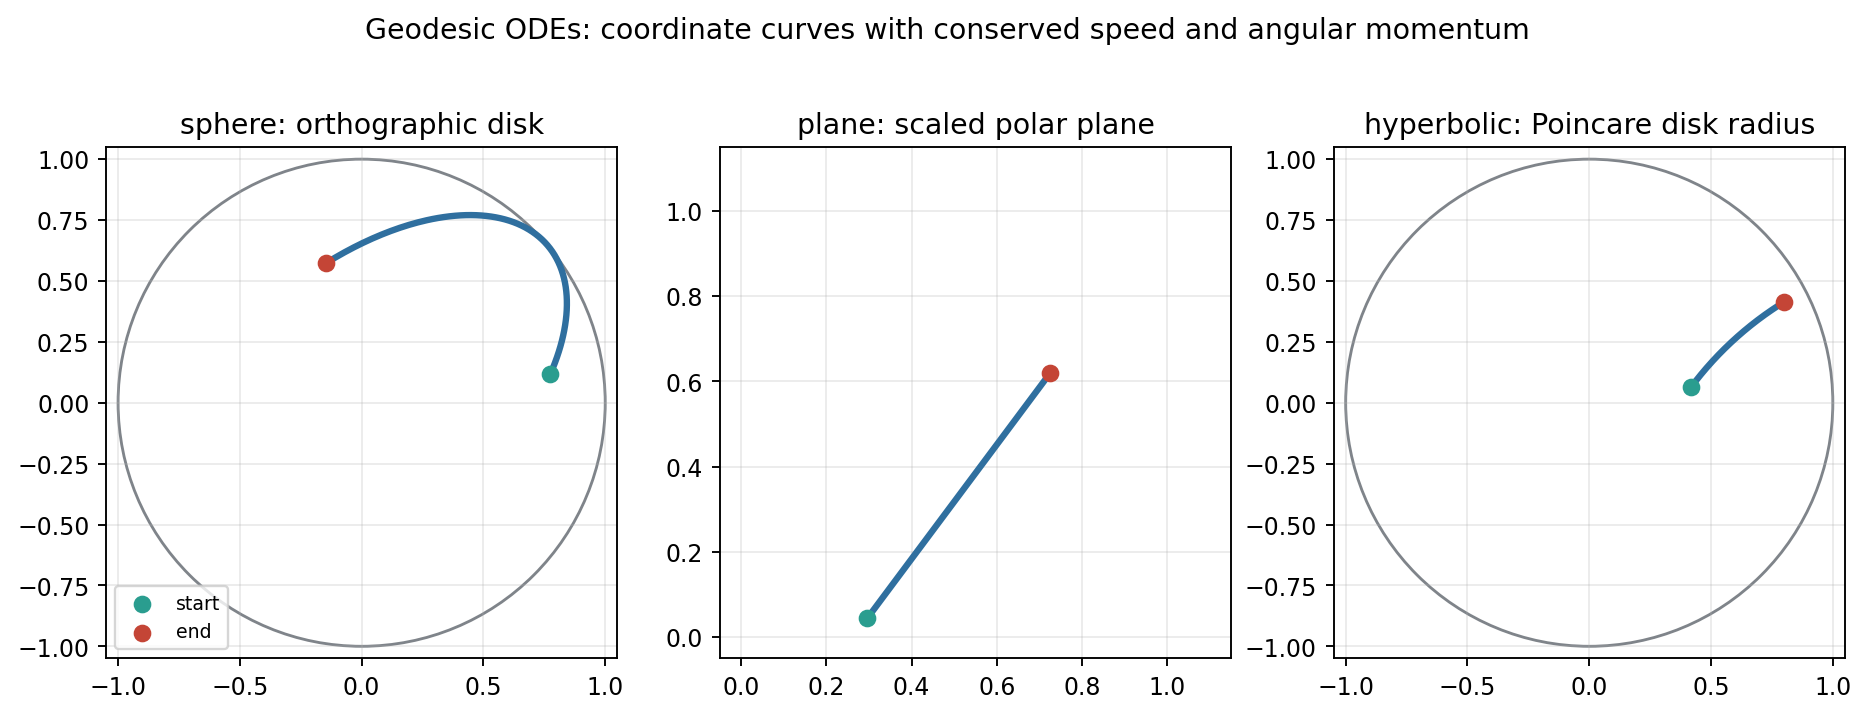

[{'model': 'sphere',
  'samples': 146,
  'speed2_initial': 1.0,
  'max_speed2_drift': 2.928102205146388e-12,
  'momentum_initial': 0.5508976940468687,
  'max_momentum_drift': 2.0586865545624278e-12},
 {'model': 'plane',
  'samples': 146,
  'speed2_initial': 1.0,
  'max_speed2_drift': 8.648637361829969e-13,
  'momentum_initial': 0.6329514772803693,
  'max_momentum_drift': 2.694511280765255e-13},
 {'model': 'hyperbolic',
  'samples': 146,
  'speed2_initial': 1.0,
  'max_speed2_drift': 9.85878045867139e-13,
  'momentum_initial': 0.7219280866555523,
  'max_momentum_drift': 1.5717538381920804e-11}]

In [3]:
def model_functions(name: str):
    if name == "sphere":
        return math.sin, math.cos, lambda r: math.sin(r), "orthographic disk"
    if name == "plane":
        return lambda r: r, lambda r: 1.0, lambda r: r / 3.0, "scaled polar plane"
    if name == "hyperbolic":
        return math.sinh, math.cosh, lambda r: math.tanh(r / 2.0), "Poincare disk radius"
    raise ValueError(name)


def integrate_geodesic_model(name: str, r0=0.9, theta0=0.15, alpha=0.78, smax=2.15):
    fnum, fpnum, radial_to_plot, _ = model_functions(name)
    y0 = np.array([r0, theta0, math.cos(alpha), math.sin(alpha) / fnum(r0)], dtype=float)
    def ode(_s, y):
        r, theta, rdot, thetadot = y
        fr = fnum(r)
        fpr = fpnum(r)
        return [rdot, thetadot, fr * fpr * thetadot**2, -2.0 * fpr / fr * rdot * thetadot]
    sol = solve_ivp(ode, (0.0, smax), y0, rtol=1e-10, atol=1e-12, max_step=0.015)
    r = sol.y[0]
    theta = sol.y[1]
    rdot = sol.y[2]
    thetadot = sol.y[3]
    fvals = np.array([fnum(float(rv)) for rv in r])
    speed2 = rdot**2 + (fvals * thetadot) ** 2
    momentum = fvals**2 * thetadot
    rho = np.array([radial_to_plot(float(rv)) for rv in r])
    return {"s": sol.t, "r": r, "theta": theta, "x": rho * np.cos(theta), "y": rho * np.sin(theta), "speed2": speed2, "momentum": momentum, "success": sol.success}

models = ["sphere", "plane", "hyperbolic"]
solutions = {name: integrate_geodesic_model(name) for name in models}
for item in solutions.values():
    assert item["success"]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.25))
for ax, name in zip(axes, models):
    sol = solutions[name]
    ax.plot(sol["x"], sol["y"], color=COLORS["blue"], lw=2.7)
    ax.scatter([sol["x"][0]], [sol["y"][0]], color=COLORS["green"], s=42, label="start", zorder=3)
    ax.scatter([sol["x"][-1]], [sol["y"][-1]], color=COLORS["red"], s=42, label="end", zorder=3)
    if name in {"sphere", "hyperbolic"}:
        ax.add_patch(Circle((0, 0), 1.0, fill=False, lw=1.2, color=COLORS["ink"], alpha=0.55))
        ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
    else:
        ax.set_xlim(-0.05, 1.15); ax.set_ylim(-0.05, 1.15)
    _, _, _, note = model_functions(name)
    ax.set_title(f"{name}: {note}")
    ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.25)
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Geodesic ODEs: coordinate curves with conserved speed and angular momentum", y=1.03)
geodesic_flow_path = save_figure(fig, "geodesic-equations-constant-curvature-flow.png", "geodesic differential equations", "path shape in three constant-curvature models generated from the same ODE template")

ode_rows = []
for name, sol in solutions.items():
    ode_rows.append({"model": name, "samples": int(len(sol["s"])), "speed2_initial": float(sol["speed2"][0]), "max_speed2_drift": float(np.max(np.abs(sol["speed2"] - sol["speed2"][0]))), "momentum_initial": float(sol["momentum"][0]), "max_momentum_drift": float(np.max(np.abs(sol["momentum"] - sol["momentum"][0])))} )
assert max(row["max_speed2_drift"] for row in ode_rows) < 2e-8
assert max(row["max_momentum_drift"] for row in ode_rows) < 2e-8
ode_table_path = write_csv_artifact("geodesic-equation-ode-invariants.csv", ode_rows, "geodesic differential equations", "numerical conservation of speed and angular momentum")
ode_check_path = write_json_artifact("geodesic-equation-ode-checks.json", {"source_span": SOURCE_SPAN, "models": ode_rows}, "geodesic differential equations", "ODE solver drift tolerances for geodesic invariants")
CHECK_RESULTS["geodesic_ode"] = {"models": ode_rows}
show_artifact(geodesic_flow_path, "ODE-generated geodesics", width=900)
display(ode_rows)

## 3. Integral Curvature of Geodesic Triangles

For a geodesic triangle on a smooth surface,

`int_triangle K dS = A + B + C - pi`.

On a sphere this is angular excess. In the hyperbolic plane it is negative, so the positive area is the angular defect `pi - A - B - C`. The figure uses one concrete spherical triangle and one abstract hyperbolic angle budget. The point to inspect is the sign: curvature is not an extra decoration on top of the angle sum; it is the missing or surplus part of the angle sum.

**Triangle curvature budget**  
`artifacts/chapter-20/figures/geodesic-triangle-curvature-budget.png`

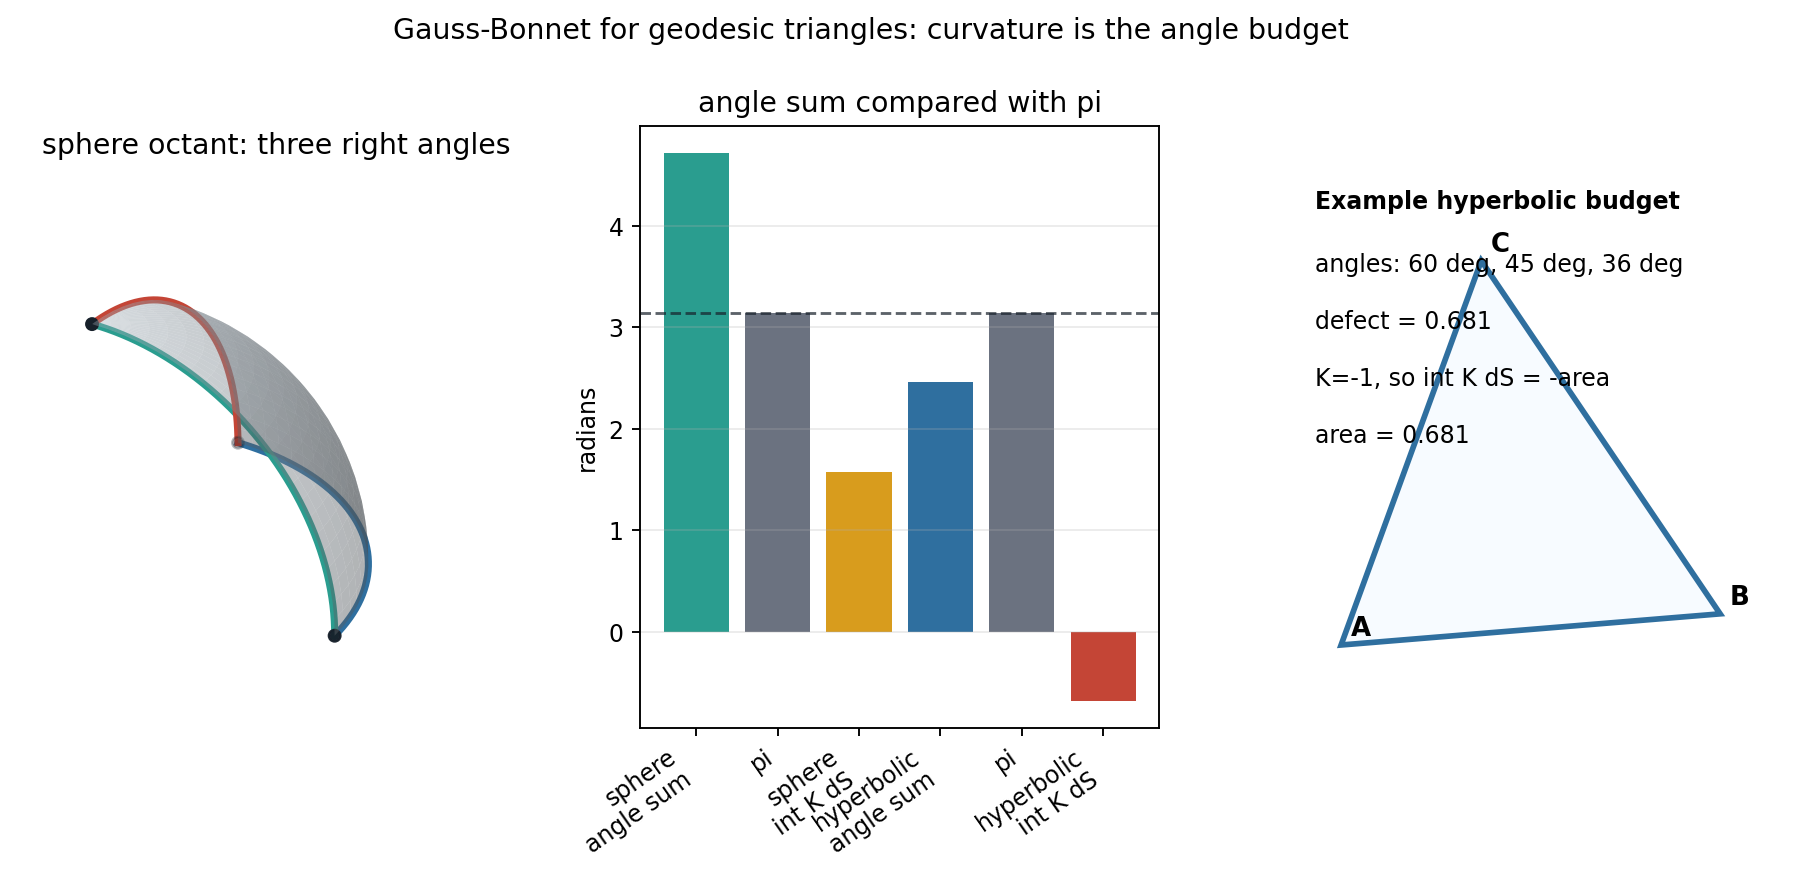

[{'model': 'unit sphere octant',
  'A_rad': np.float64(1.5707963267948966),
  'B_rad': np.float64(1.5707963267948966),
  'C_rad': np.float64(1.5707963267948966),
  'angle_sum_minus_pi': np.float64(1.5707963267948966),
  'signed_integral_K_dS': 1.5707963267948966,
  'area': 1.5707963267948966},
 {'model': 'hyperbolic K=-1 example',
  'A_rad': np.float64(1.0471975511965976),
  'B_rad': np.float64(0.7853981633974483),
  'C_rad': np.float64(0.6283185307179586),
  'angle_sum_minus_pi': np.float64(-0.6806784082777888),
  'signed_integral_K_dS': -0.6806784082777888,
  'area': 0.6806784082777888}]

In [4]:
spherical_angles = np.array([math.pi / 2, math.pi / 2, math.pi / 2])
spherical_area = math.pi / 2
spherical_integral = spherical_area
hyperbolic_angles = np.array([math.pi / 3, math.pi / 4, math.pi / 5])
hyperbolic_defect = math.pi - float(hyperbolic_angles.sum())
hyperbolic_area = hyperbolic_defect
hyperbolic_integral = -hyperbolic_area
assert abs(float(spherical_angles.sum()) - math.pi - spherical_integral) < 1e-12
assert abs(float(hyperbolic_angles.sum()) - math.pi - hyperbolic_integral) < 1e-12

fig = plt.figure(figsize=(13.4, 4.6))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
phi = np.linspace(0, math.pi / 2, 50)
th = np.linspace(0, math.pi / 2, 24)
ph = np.linspace(0, math.pi / 2, 24)
TH, PH = np.meshgrid(th, ph, indexing="ij")
X = np.sin(PH) * np.cos(TH); Y = np.sin(PH) * np.sin(TH); Z = np.cos(PH)
ax1.plot_surface(X, Y, Z, color="#d7e7f3", alpha=0.45, linewidth=0)
ax1.plot(np.cos(phi), np.sin(phi), np.zeros_like(phi), color=COLORS["blue"], lw=3)
ax1.plot(np.cos(phi), np.zeros_like(phi), np.sin(phi), color=COLORS["green"], lw=3)
ax1.plot(np.zeros_like(phi), np.cos(phi), np.sin(phi), color=COLORS["red"], lw=3)
ax1.scatter([1, 0, 0], [0, 1, 0], [0, 0, 1], color=COLORS["ink"], s=24)
ax1.set_title("sphere octant: three right angles")
ax1.set_axis_off(); ax1.set_box_aspect((1, 1, 1))

ax2 = fig.add_subplot(1, 3, 2)
labels = ["sphere\nangle sum", "pi", "sphere\nint K dS", "hyperbolic\nangle sum", "pi", "hyperbolic\nint K dS"]
values = [spherical_angles.sum(), math.pi, spherical_integral, hyperbolic_angles.sum(), math.pi, hyperbolic_integral]
colors = [COLORS["green"], COLORS["gray"], COLORS["gold"], COLORS["blue"], COLORS["gray"], COLORS["red"]]
ax2.bar(range(len(values)), values, color=colors)
ax2.axhline(math.pi, color=COLORS["ink"], lw=1.2, ls="--", alpha=0.7)
ax2.set_xticks(range(len(values))); ax2.set_xticklabels(labels, rotation=35, ha="right")
ax2.set_ylabel("radians"); ax2.set_title("angle sum compared with pi"); ax2.grid(axis="y", alpha=0.25)

ax3 = fig.add_subplot(1, 3, 3)
tri = np.array([[0.15, 0.08], [0.88, 0.14], [0.42, 0.82]])
ax3.add_patch(Polygon(tri, closed=True, facecolor="#f7fbff", edgecolor=COLORS["blue"], lw=2.4))
for point, label in zip(tri, ["A", "B", "C"]):
    ax3.text(point[0] + 0.018, point[1] + 0.018, label, fontsize=11, weight="bold")
ax3.text(0.10, 0.92, "Example hyperbolic budget", weight="bold")
ax3.text(0.10, 0.80, "angles: 60 deg, 45 deg, 36 deg")
ax3.text(0.10, 0.69, f"defect = {hyperbolic_defect:.3f}")
ax3.text(0.10, 0.58, "K=-1, so int K dS = -area")
ax3.text(0.10, 0.47, f"area = {hyperbolic_area:.3f}")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect("equal"); ax3.axis("off")
fig.suptitle("Gauss-Bonnet for geodesic triangles: curvature is the angle budget", y=1.02)
triangle_path = save_figure(fig, "geodesic-triangle-curvature-budget.png", "integral curvature of geodesic triangles", "positive spherical excess and negative hyperbolic curvature integral")
triangle_rows = [
    {"model": "unit sphere octant", "A_rad": spherical_angles[0], "B_rad": spherical_angles[1], "C_rad": spherical_angles[2], "angle_sum_minus_pi": spherical_angles.sum() - math.pi, "signed_integral_K_dS": spherical_integral, "area": spherical_area},
    {"model": "hyperbolic K=-1 example", "A_rad": hyperbolic_angles[0], "B_rad": hyperbolic_angles[1], "C_rad": hyperbolic_angles[2], "angle_sum_minus_pi": hyperbolic_angles.sum() - math.pi, "signed_integral_K_dS": hyperbolic_integral, "area": hyperbolic_area},
]
triangle_table_path = write_csv_artifact("geodesic-triangle-curvature-budget.csv", triangle_rows, "integral curvature of geodesic triangles", "angle sums, signed curvature integrals, and areas")
triangle_check_payload = {"source_span": SOURCE_SPAN, "rows": triangle_rows}
triangle_check_path = write_json_artifact("geodesic-triangle-curvature-checks.json", triangle_check_payload, "integral curvature of geodesic triangles", "Gauss-Bonnet angle excess and defect identities")
CHECK_RESULTS["triangle_curvature"] = triangle_check_payload
show_artifact(triangle_path, "Triangle curvature budget", width=920)
display(triangle_rows)

## 4. Euler-Poincare Characteristic as Total Curvature

The source extends the triangle formula from one geodesic triangle to a map on a closed surface. When all triangle budgets are added, interior edge contributions cancel and the result is global:

`int_surface K dS = 2 pi chi`, where `chi = V - E + F`.

The next artifact treats this as a ledger. A tetrahedron on a sphere has four vertices with angle deficit `pi`, so the total is `4 pi = 2 pi * 2`. A flat triangular torus has six equilateral angles around every vertex, so the total deficit and `chi` are both zero.

**Euler-Poincare curvature ledger**  
`artifacts/chapter-20/figures/euler-poincare-total-curvature-ledger.png`

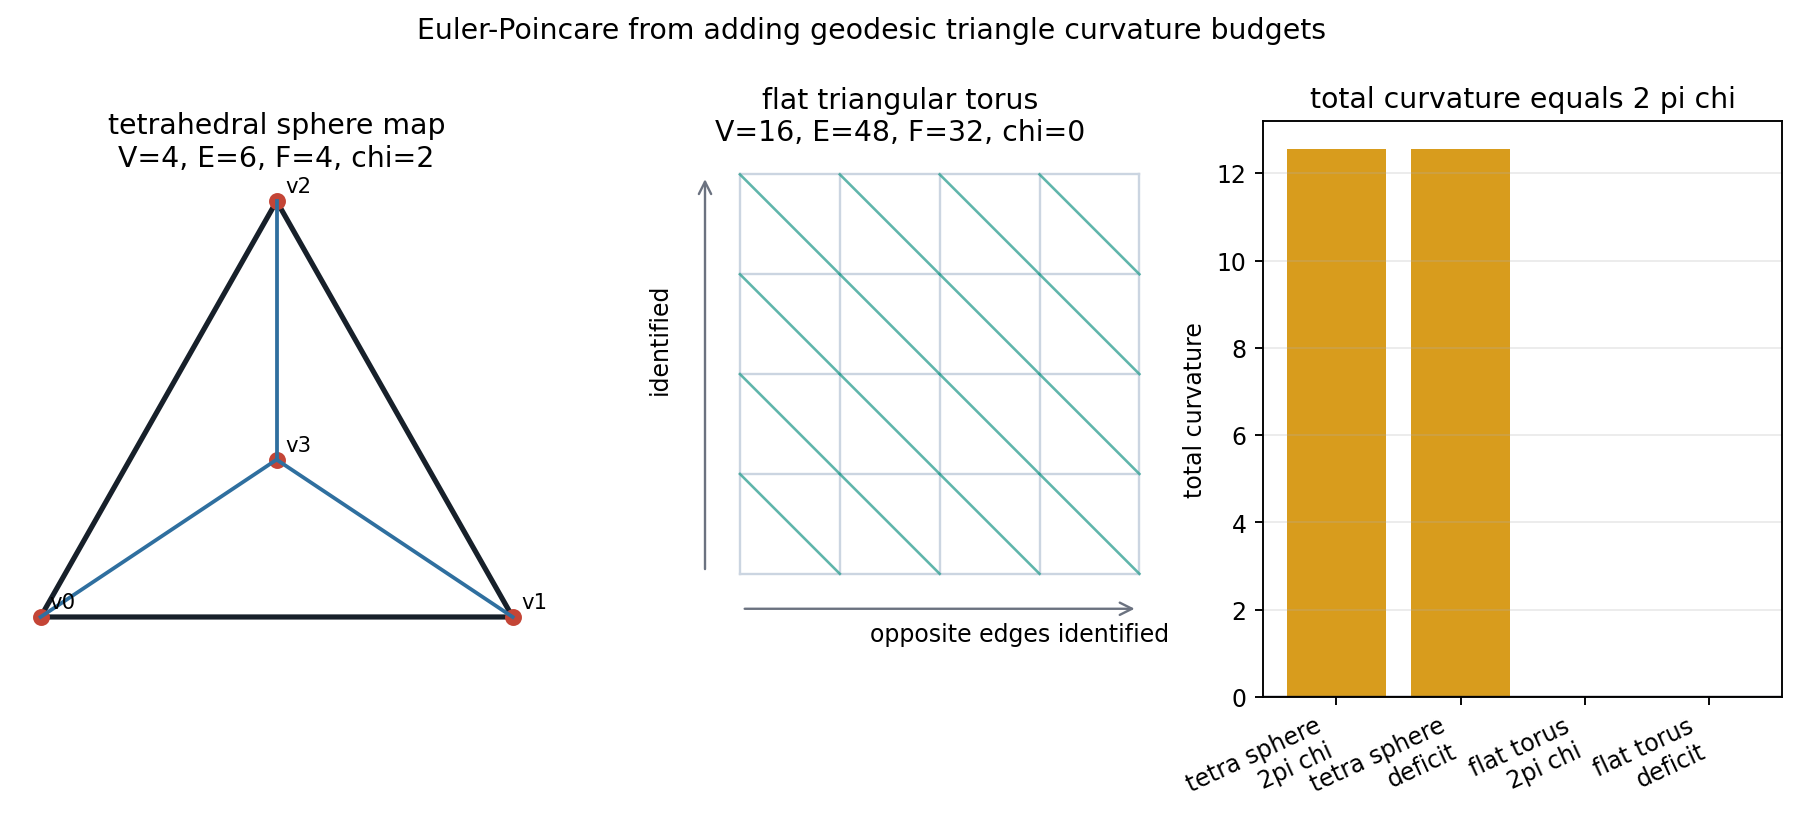

[{'surface_model': 'tetrahedral sphere',
  'V': 4,
  'E': 6,
  'F': 4,
  'chi': 2,
  'total_curvature': 12.56637061435917,
  'two_pi_chi': 12.566370614359172},
 {'surface_model': 'periodic triangular torus',
  'V': 16,
  'E': 48,
  'F': 32,
  'chi': 0,
  'total_curvature': 0.0,
  'two_pi_chi': 0.0}]

In [5]:
def mesh_edges(faces):
    edges = set()
    for face in faces:
        for i in range(len(face)):
            a, b = sorted((face[i], face[(i + 1) % len(face)]))
            edges.add((a, b))
    return edges


def triangle_angle(a, b, c):
    ba = a - b; bc = c - b
    return math.acos(float(np.clip(np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc)), -1.0, 1.0)))

tetra_vertices = np.array([[1, 1, 1], [1, -1, -1], [-1, 1, -1], [-1, -1, 1]], dtype=float)
tetra_faces = [(0, 1, 2), (0, 3, 1), (0, 2, 3), (1, 3, 2)]
tetra_edges = mesh_edges(tetra_faces)
tetra_angle_sums = {i: 0.0 for i in range(len(tetra_vertices))}
for face in tetra_faces:
    for idx, vertex_id in enumerate(face):
        tetra_angle_sums[vertex_id] += triangle_angle(tetra_vertices[face[(idx - 1) % 3]], tetra_vertices[vertex_id], tetra_vertices[face[(idx + 1) % 3]])
tetra_deficits = {i: 2 * math.pi - angle_sum for i, angle_sum in tetra_angle_sums.items()}
tetra_chi = len(tetra_vertices) - len(tetra_edges) + len(tetra_faces)
tetra_total_deficit = sum(tetra_deficits.values())
assert tetra_chi == 2
assert abs(tetra_total_deficit - 2 * math.pi * tetra_chi) < 1e-12

n, m = 4, 4
torus_vertices = [(i, j) for i in range(n) for j in range(m)]
def vid(i, j):
    return (i % n) * m + (j % m)
torus_faces = []
for i in range(n):
    for j in range(m):
        torus_faces.append((vid(i, j), vid(i + 1, j), vid(i, j + 1)))
        torus_faces.append((vid(i + 1, j + 1), vid(i, j + 1), vid(i + 1, j)))
torus_edges = mesh_edges(torus_faces)
torus_chi = len(torus_vertices) - len(torus_edges) + len(torus_faces)
torus_total_deficit = 0.0
assert torus_chi == 0
assert len(torus_edges) == 3 * n * m
assert len(torus_faces) == 2 * n * m

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.4))
ax = axes[0]
outer = np.array([[0.08, 0.08], [0.92, 0.08], [0.50, 0.82]])
center = np.array([0.50, 0.36])
for p in outer:
    ax.plot([center[0], p[0]], [center[1], p[1]], color=COLORS["blue"], lw=1.6)
ax.add_patch(Polygon(outer, closed=True, fill=False, edgecolor=COLORS["ink"], lw=2.2))
for i, p in enumerate([*outer, center]):
    ax.scatter([p[0]], [p[1]], color=COLORS["red"], s=38); ax.text(p[0] + 0.015, p[1] + 0.015, f"v{i}", fontsize=9)
ax.set_title("tetrahedral sphere map\nV=4, E=6, F=4, chi=2"); ax.axis("off"); ax.set_aspect("equal")

ax = axes[1]
for i in range(n + 1): ax.plot([i, i], [0, m], color="#cbd5e1", lw=1)
for j in range(m + 1): ax.plot([0, n], [j, j], color="#cbd5e1", lw=1)
for i in range(n):
    for j in range(m): ax.plot([i, i + 1], [j + 1, j], color=COLORS["green"], lw=1.1, alpha=0.75)
ax.add_patch(FancyArrowPatch((0, -0.35), (n, -0.35), arrowstyle="->", mutation_scale=13, color=COLORS["gray"]))
ax.add_patch(FancyArrowPatch((-0.35, 0), (-0.35, m), arrowstyle="->", mutation_scale=13, color=COLORS["gray"]))
ax.text(n / 2 - 0.7, -0.68, "opposite edges identified"); ax.text(-0.92, m / 2 - 0.15, "identified", rotation=90)
ax.set_xlim(-1.0, n + 0.2); ax.set_ylim(-0.9, m + 0.2)
ax.set_title("flat triangular torus\nV=16, E=48, F=32, chi=0"); ax.axis("off"); ax.set_aspect("equal")

ax = axes[2]
ledger_labels = ["tetra sphere\n2pi chi", "tetra sphere\ndeficit", "flat torus\n2pi chi", "flat torus\ndeficit"]
ledger_values = [2 * math.pi * tetra_chi, tetra_total_deficit, 2 * math.pi * torus_chi, torus_total_deficit]
ax.bar(range(4), ledger_values, color=[COLORS["gold"], COLORS["gold"], COLORS["violet"], COLORS["violet"]])
ax.axhline(0, color=COLORS["ink"], lw=1); ax.set_xticks(range(4)); ax.set_xticklabels(ledger_labels, rotation=25, ha="right")
ax.set_ylabel("total curvature"); ax.set_title("total curvature equals 2 pi chi"); ax.grid(axis="y", alpha=0.25)
fig.suptitle("Euler-Poincare from adding geodesic triangle curvature budgets", y=1.02)
euler_path = save_figure(fig, "euler-poincare-total-curvature-ledger.png", "Euler-Poincare characteristic", "V-E+F and total angle deficit agree with 2 pi chi")
euler_rows = [
    {"surface_model": "tetrahedral sphere", "V": len(tetra_vertices), "E": len(tetra_edges), "F": len(tetra_faces), "chi": tetra_chi, "total_curvature": tetra_total_deficit, "two_pi_chi": 2 * math.pi * tetra_chi},
    {"surface_model": "periodic triangular torus", "V": len(torus_vertices), "E": len(torus_edges), "F": len(torus_faces), "chi": torus_chi, "total_curvature": torus_total_deficit, "two_pi_chi": 2 * math.pi * torus_chi},
]
euler_table_path = write_csv_artifact("euler-poincare-curvature-ledger.csv", euler_rows, "Euler-Poincare characteristic", "mesh counts and total curvature ledger")
euler_check_path = write_json_artifact("euler-poincare-curvature-checks.json", {"source_span": SOURCE_SPAN, "rows": euler_rows, "max_total_error": max(abs(r["total_curvature"] - r["two_pi_chi"]) for r in euler_rows)}, "Euler-Poincare characteristic", "closed-surface total curvature equals 2 pi times Euler characteristic")
CHECK_RESULTS["euler_poincare"] = {"rows": euler_rows}
show_artifact(euler_path, "Euler-Poincare curvature ledger", width=930)
display(euler_rows)

## 5. Constant-Curvature Metrics and Geodesic Circles

In geodesic polar coordinates, constant curvature is encoded by one radial function:

`ds^2 = dr^2 + f(r)^2 dtheta^2`, and `K = -f''(r) / f(r)`.

The three standard choices are `f(r)=sin r`, `f(r)=r`, and `f(r)=sinh r`. The circumference of a geodesic circle is `2 pi f(r)`. For small `r`, all three look Euclidean; for larger `r`, positive curvature makes circles smaller than Euclidean and negative curvature makes them larger.

**Constant-curvature circle growth**  
`artifacts/chapter-20/figures/constant-curvature-geodesic-circles.png`

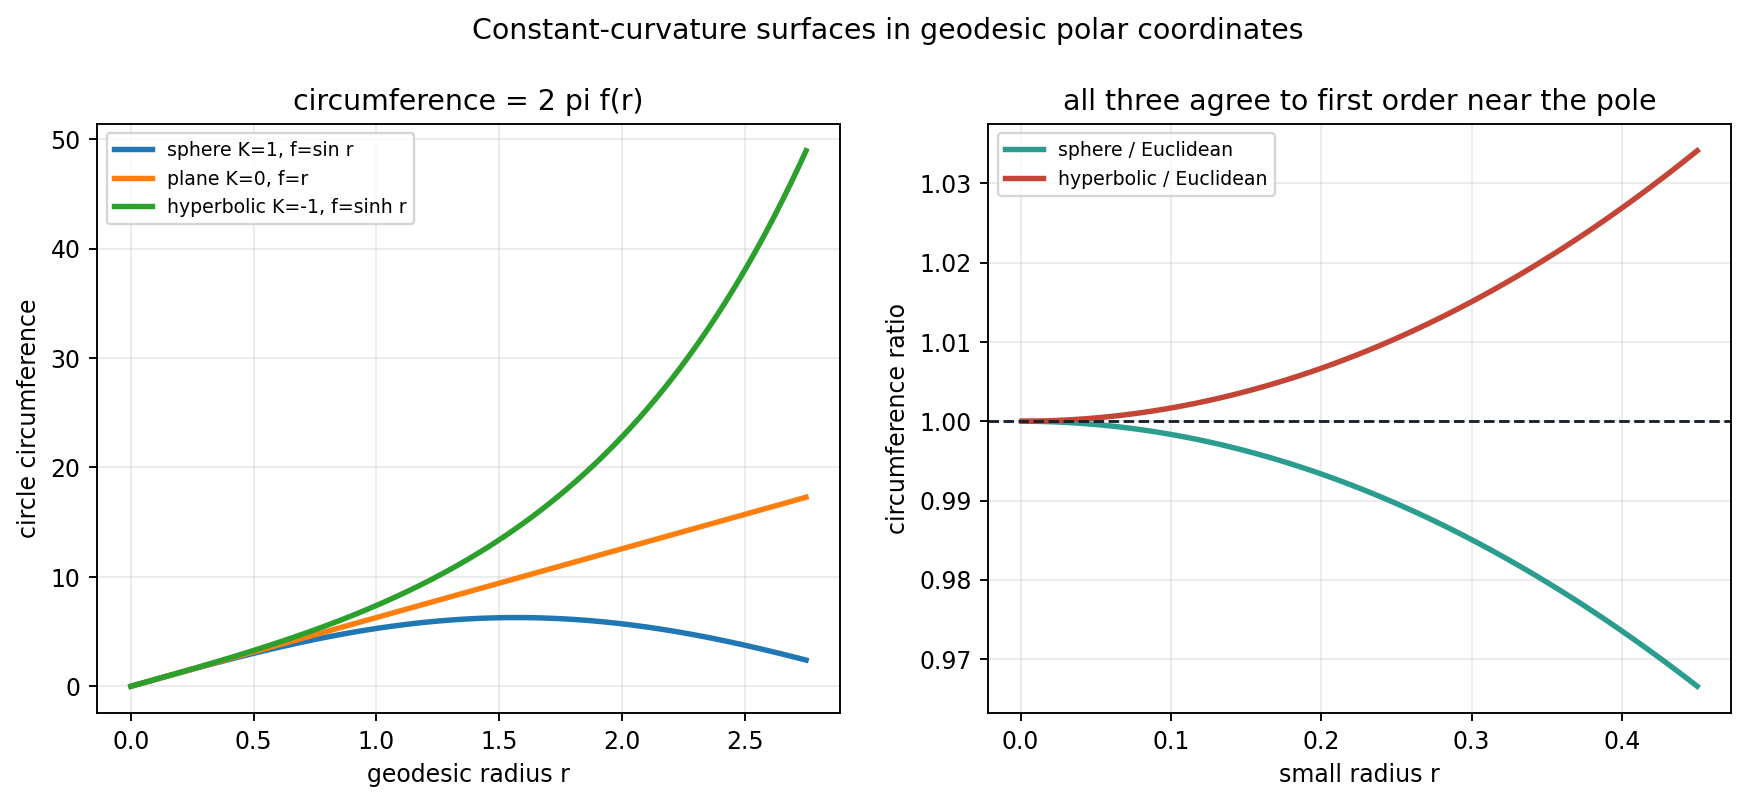

{'sphere_f_sin_r': '1', 'plane_f_r': '0', 'hyperbolic_f_sinh_r': '-1'}

In [6]:
r = sp.symbols("r", positive=True)
symbolic_curvatures = {"sphere_f_sin_r": str(sp.simplify(-sp.diff(sp.sin(r), r, 2) / sp.sin(r))), "plane_f_r": str(sp.simplify(-sp.diff(r, r, 2) / r)), "hyperbolic_f_sinh_r": str(sp.simplify(-sp.diff(sp.sinh(r), r, 2) / sp.sinh(r)))}
assert symbolic_curvatures == {"sphere_f_sin_r": "1", "plane_f_r": "0", "hyperbolic_f_sinh_r": "-1"}
rr = np.linspace(0.001, 2.75, 400)
curves = {"sphere K=1, f=sin r": np.sin(rr), "plane K=0, f=r": rr, "hyperbolic K=-1, f=sinh r": np.sinh(rr)}
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.5))
for label, fvals in curves.items():
    axes[0].plot(rr, 2 * math.pi * fvals, lw=2.3, label=label)
axes[0].set_xlabel("geodesic radius r"); axes[0].set_ylabel("circle circumference"); axes[0].set_title("circumference = 2 pi f(r)"); axes[0].grid(alpha=0.25); axes[0].legend(fontsize=8)
small_rr = np.linspace(0.001, 0.45, 120)
axes[1].plot(small_rr, np.sin(small_rr) / small_rr, label="sphere / Euclidean", color=COLORS["green"], lw=2.3)
axes[1].plot(small_rr, np.sinh(small_rr) / small_rr, label="hyperbolic / Euclidean", color=COLORS["red"], lw=2.3)
axes[1].axhline(1, color=COLORS["ink"], lw=1.2, ls="--")
axes[1].set_xlabel("small radius r"); axes[1].set_ylabel("circumference ratio"); axes[1].set_title("all three agree to first order near the pole"); axes[1].grid(alpha=0.25); axes[1].legend(fontsize=8)
fig.suptitle("Constant-curvature surfaces in geodesic polar coordinates", y=1.02)
circle_path = save_figure(fig, "constant-curvature-geodesic-circles.png", "constant-curvature surfaces", "geodesic circle circumference separates K=1, K=0, and K=-1")
ledger_r = [0.25, 0.75, 1.25, 1.75, 2.25]
circle_rows = [{"r": rv, "sphere_circumference": 2 * math.pi * math.sin(rv), "euclidean_circumference": 2 * math.pi * rv, "hyperbolic_circumference": 2 * math.pi * math.sinh(rv)} for rv in ledger_r]
circle_table_path = write_csv_artifact("constant-curvature-geodesic-circle-circumferences.csv", circle_rows, "constant-curvature surfaces", "circle circumference samples for positive, zero, and negative curvature")
circle_check_path = write_json_artifact("constant-curvature-metric-checks.json", {"source_span": SOURCE_SPAN, "symbolic_curvatures": symbolic_curvatures, "sample_rows": circle_rows}, "constant-curvature surfaces", "symbolic K=-f''/f and sampled circumference values")
CHECK_RESULTS["constant_curvature"] = {"symbolic_curvatures": symbolic_curvatures}
show_artifact(circle_path, "Constant-curvature circle growth", width=900)
display(symbolic_curvatures)

## 6. Angle of Parallelism

In the hyperbolic case, a point at distance `a` from a line has a limiting parallel that makes an angle `Pi(a)` with the perpendicular. The source derives the Lobachevsky formula

`Pi(a) = 2 arctan(exp(-a))`.

This is a direct computational test of the geometry. As distance grows, the limiting angle shrinks. The companion identities `cos(Pi(a)) = tanh(a)` and `sin(Pi(a)) = sech(a)` let the plot check itself.

**Angle of parallelism**  
`artifacts/chapter-20/figures/angle-of-parallelism-lobachevsky.png`

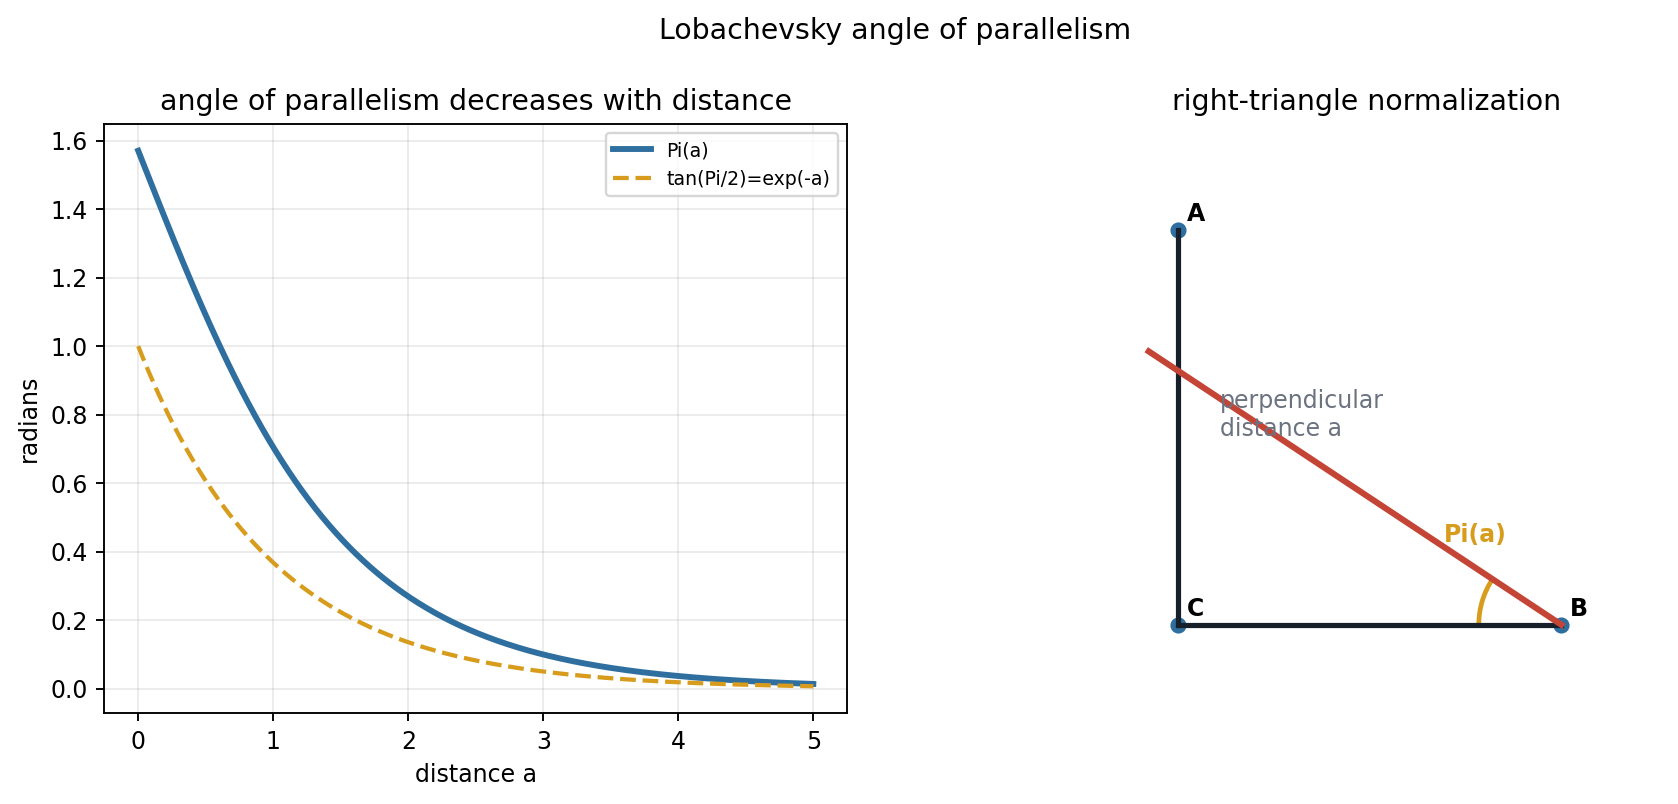

{'source_span': {'printed_pages': '366-378',
  'pdf_pages': '384-396',
  'source_map': 'pdf_page = printed_page + 18',
  'inspection_method': 'temporary rendered page images from the scanned PDF'},
 'strictly_decreasing': True,
 'identity_cos_error': 1.6653345369377348e-16,
 'identity_sin_error': 2.220446049250313e-16,
 'half_angle_error': 1.1102230246251565e-16}

In [7]:
a = np.linspace(0.0, 5.0, 400)
Pi = 2 * np.arctan(np.exp(-a))
identity_cos_error = float(np.max(np.abs(np.cos(Pi) - np.tanh(a))))
identity_sin_error = float(np.max(np.abs(np.sin(Pi) - sech(a))))
half_angle_error = float(np.max(np.abs(np.tan(Pi / 2) - np.exp(-a))))
assert identity_cos_error < 1e-14 and identity_sin_error < 1e-14 and half_angle_error < 1e-14
assert np.all(np.diff(Pi) < 0)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.5))
axes[0].plot(a, Pi, color=COLORS["blue"], lw=2.5, label="Pi(a)")
axes[0].plot(a, np.exp(-a), color=COLORS["gold"], lw=1.8, ls="--", label="tan(Pi/2)=exp(-a)")
axes[0].set_xlabel("distance a"); axes[0].set_ylabel("radians"); axes[0].set_title("angle of parallelism decreases with distance"); axes[0].grid(alpha=0.25); axes[0].legend(fontsize=8)
ax = axes[1]
C = np.array([0.18, 0.15]); A = np.array([0.18, 0.82]); B = np.array([0.83, 0.15])
ax.plot([C[0], A[0]], [C[1], A[1]], color=COLORS["ink"], lw=2.2)
ax.plot([C[0], B[0]], [C[1], B[1]], color=COLORS["ink"], lw=2.2)
sample_a = 1.2; sample_pi = 2 * math.atan(math.exp(-sample_a))
D = B + 0.84 * np.array([math.cos(math.pi - sample_pi), math.sin(math.pi - sample_pi)])
ax.plot([B[0], D[0]], [B[1], D[1]], color=COLORS["red"], lw=2.6)
ax.scatter([A[0], B[0], C[0]], [A[1], B[1], C[1]], color=COLORS["blue"], s=34)
for point, label in [(A, "A"), (B, "B"), (C, "C")]: ax.text(point[0] + 0.015, point[1] + 0.015, label, weight="bold")
ax.add_patch(Arc(B, 0.28, 0.28, theta1=180 - math.degrees(sample_pi), theta2=180, color=COLORS["gold"], lw=2))
ax.text(B[0] - 0.20, B[1] + 0.14, "Pi(a)", color=COLORS["gold"], weight="bold")
ax.text(0.25, 0.47, "perpendicular\ndistance a", color=COLORS["gray"])
ax.set_title("right-triangle normalization"); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Lobachevsky angle of parallelism", y=1.02)
angle_path = save_figure(fig, "angle-of-parallelism-lobachevsky.png", "angle of parallelism", "Pi(a) is monotone and satisfies the hyperbolic right-triangle identities")
angle_rows = []
for av in [0.0, 0.5, 1.0, 1.5, 2.5, 4.0]:
    piv = 2 * math.atan(math.exp(-av))
    angle_rows.append({"a": av, "Pi_radians": piv, "Pi_degrees": math.degrees(piv), "tan_half_Pi": math.tan(piv / 2), "exp_minus_a": math.exp(-av), "cos_Pi": math.cos(piv), "tanh_a": math.tanh(av)})
angle_table_path = write_csv_artifact("angle-of-parallelism-values.csv", angle_rows, "angle of parallelism", "sample values and half-angle identity")
angle_check_payload = {"source_span": SOURCE_SPAN, "strictly_decreasing": bool(np.all(np.diff(Pi) < 0)), "identity_cos_error": identity_cos_error, "identity_sin_error": identity_sin_error, "half_angle_error": half_angle_error}
angle_check_path = write_json_artifact("angle-of-parallelism-checks.json", angle_check_payload, "angle of parallelism", "monotonicity and Lobachevsky identity residuals")
CHECK_RESULTS["angle_of_parallelism"] = angle_check_payload
show_artifact(angle_path, "Angle of parallelism", width=900)
display(angle_check_payload)

## 7. The Pseudosphere

The pseudosphere is obtained by revolving a tractrix. A convenient parametrization is

`x = sech(u) cos(v)`, `y = sech(u) sin(v)`, `z = u - tanh(u)`.

Its first fundamental form is `tanh(u)^2 du^2 + sech(u)^2 dv^2`, and the curvature check below gives `K=-1`. That does not mean the whole hyperbolic plane has been embedded. The cusp edge at `u=0` cuts off the surface. In the artifact, meridians are drawn as geodesic representatives and horizontal circles as horocycle representatives; the missing edge is part of the lesson.

In [8]:
u_sym = sp.symbols("u", positive=True)
A_metric = sp.tanh(u_sym); B_metric = sp.sech(u_sym)
K_pseudosphere = sp.simplify(-(1 / (A_metric * B_metric)) * sp.diff(sp.diff(B_metric, u_sym) / A_metric, u_sym))
assert str(K_pseudosphere) == "-1"
E_metric = sp.simplify(A_metric**2); G_metric = sp.simplify(B_metric**2)
assert str(E_metric) == "tanh(u)**2" and str(G_metric) == "sech(u)**2"
u_vals = np.linspace(0.12, 4.2, 110); v_vals = np.linspace(0, 2 * math.pi, 130)
U, V = np.meshgrid(u_vals, v_vals, indexing="ij")
R = sech(U); X = R * np.cos(V); Y = R * np.sin(V); Z = U - np.tanh(U)
ps_fig = go.Figure()
ps_fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale="Viridis", showscale=False, opacity=0.9, name="pseudosphere"))
for vv in np.linspace(0, 2 * math.pi, 9, endpoint=False):
    ru = sech(u_vals)
    show_meridian = bool(abs(float(vv)) < 1e-12)
    ps_fig.add_trace(go.Scatter3d(x=ru * np.cos(vv), y=ru * np.sin(vv), z=u_vals - np.tanh(u_vals), mode="lines", line=dict(color="#111827", width=4), name="meridian geodesic" if show_meridian else None, showlegend=show_meridian))
for uu in [0.35, 0.75, 1.25, 2.0, 3.1]:
    rv = sech(uu)
    show_horocycle = bool(abs(float(uu) - 0.35) < 1e-9)
    ps_fig.add_trace(go.Scatter3d(x=rv * np.cos(v_vals), y=rv * np.sin(v_vals), z=np.full_like(v_vals, uu - math.tanh(uu)), mode="lines", line=dict(color="#d89c1d", width=5), name="horocycle circle" if show_horocycle else None, showlegend=show_horocycle))
ps_fig.update_layout(title="Pseudosphere: constant K=-1, but only a horocyclic sector of the hyperbolic plane", width=820, height=620, margin=dict(l=0, r=0, b=0, t=45), scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"))
pseudosphere_html = write_plotly_html(ps_fig, "pseudosphere-tractrix-negative-curvature.html", "pseudosphere", "tractrix surface with meridian geodesics and horocycle circles")
pseudosphere_check_payload = {"source_span": SOURCE_SPAN, "parametrization": {"x": "sech(u) cos(v)", "y": "sech(u) sin(v)", "z": "u - tanh(u)"}, "metric_coefficients": {"E": str(E_metric), "F": "0", "G": str(G_metric)}, "curvature": str(K_pseudosphere), "u_min_rendered": float(u_vals.min()), "u_max_rendered": float(u_vals.max()), "cusp_edge_excluded": True}
pseudosphere_check_path = write_json_artifact("pseudosphere-metric-curvature-checks.json", pseudosphere_check_payload, "pseudosphere", "metric coefficients imply K=-1 while the cusp edge limits the model")
CHECK_RESULTS["pseudosphere"] = pseudosphere_check_payload
show_artifact(pseudosphere_html, "Interactive pseudosphere", width=900)
display(pseudosphere_check_payload)

**Interactive pseudosphere**  
`artifacts/chapter-20/html/pseudosphere-tractrix-negative-curvature.html`

{'source_span': {'printed_pages': '366-378',
  'pdf_pages': '384-396',
  'source_map': 'pdf_page = printed_page + 18',
  'inspection_method': 'temporary rendered page images from the scanned PDF'},
 'parametrization': {'x': 'sech(u) cos(v)',
  'y': 'sech(u) sin(v)',
  'z': 'u - tanh(u)'},
 'metric_coefficients': {'E': 'tanh(u)**2', 'F': '0', 'G': 'sech(u)**2'},
 'curvature': '-1',
 'u_min_rendered': 0.12,
 'u_max_rendered': 4.2,
 'cusp_edge_excluded': True}

## Applied Lab: Recover Curvature from Circle Growth

The constant-curvature formula can be tested without seeing the embedding. If `C(r)` is the circumference of a small geodesic circle, then `f(r)=C(r)/(2 pi)` and `K=-f''(r)/f(r)`. The lab below samples the three model functions and estimates curvature by finite differences. Change the radius range or grid size and inspect which estimates are stable.

In [9]:
lab_r = np.linspace(0.12, 1.35, 260)
lab_models = {"sphere": (np.sin(lab_r), 1.0), "plane": (lab_r.copy(), 0.0), "hyperbolic": (np.sinh(lab_r), -1.0)}
lab_rows = []
for name, (fvals, expected_K) in lab_models.items():
    fp = np.gradient(fvals, lab_r); fpp = np.gradient(fp, lab_r); K_est = -fpp / fvals; interior = slice(8, -8)
    lab_rows.append({"model": name, "expected_K": expected_K, "mean_estimated_K": float(np.mean(K_est[interior])), "max_abs_error_interior": float(np.max(np.abs(K_est[interior] - expected_K)))})
assert max(row["max_abs_error_interior"] for row in lab_rows) < 0.03
lab_path = write_csv_artifact("geodesic-circle-curvature-recovery-lab.csv", lab_rows, "applied lab: curvature from geodesic circles", "finite-difference recovery of K from circumference growth", directory=DATA)
lab_check_path = write_json_artifact("geodesic-circle-curvature-recovery-checks.json", {"source_span": SOURCE_SPAN, "rows": lab_rows, "max_error": max(row["max_abs_error_interior"] for row in lab_rows)}, "applied lab: curvature from geodesic circles", "finite-difference curvature estimates remain close to symbolic constants")
CHECK_RESULTS["curvature_recovery_lab"] = {"rows": lab_rows}
display(Markdown(f"Lab data written to `{rel(lab_path)}`."))
display(lab_rows)

Lab data written to `artifacts/chapter-20/data/geodesic-circle-curvature-recovery-lab.csv`.

[{'model': 'sphere',
  'expected_K': 1.0,
  'mean_estimated_K': 0.9999924822455858,
  'max_abs_error_interior': 7.517759283537373e-06},
 {'model': 'plane',
  'expected_K': 0.0,
  'mean_estimated_K': -9.275120922372045e-15,
  'max_abs_error_interior': 4.124373025925506e-12},
 {'model': 'hyperbolic',
  'expected_K': -1.0,
  'mean_estimated_K': -1.0000075177996157,
  'max_abs_error_interior': 7.5178063854153265e-06}]

## Proof and Invariant Scaffold

The chapter's proof movement can be read as a chain of invariants.

1. The first fundamental form gives Christoffel symbols.
2. Christoffel symbols give the geodesic equations.
3. In geodesic polar coordinates, the metric has the form `dr^2 + f(r)^2 dtheta^2`.
4. The same `f` gives both Gaussian curvature `K=-f''/f` and geodesic circle circumference `2 pi f(r)`.
5. Adding the geodesic-triangle identity over a closed map cancels edge terms and leaves `2 pi (V-E+F)`.

The computational checks are deliberately small versions of this chain. They do not replace the proof; they make the quantities in the proof inspectable and auditable.

**Proof invariant scaffold**  
`artifacts/chapter-20/figures/geodesics-proof-invariant-scaffold.png`

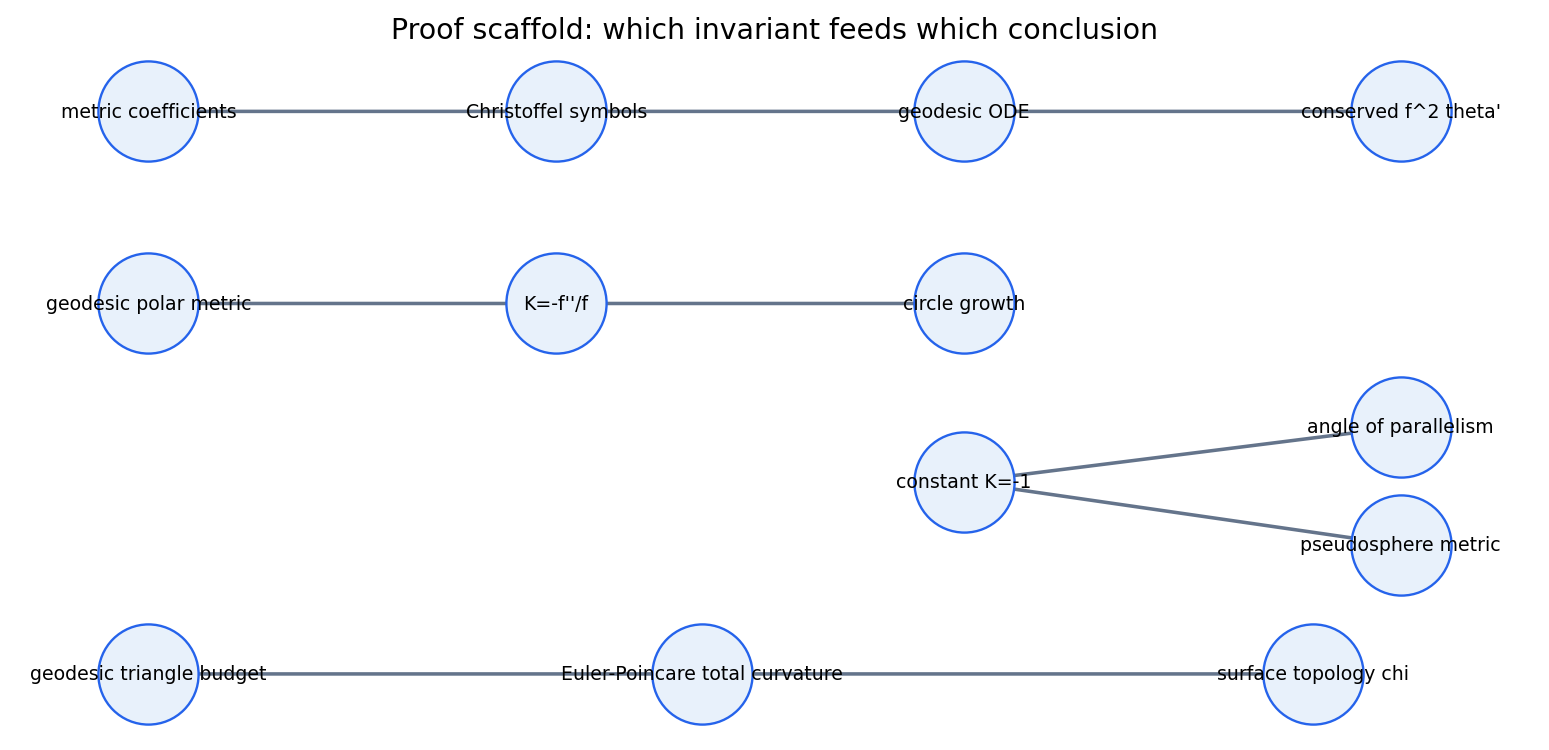

In [10]:
proof_edges = [("metric coefficients", "Christoffel symbols"), ("Christoffel symbols", "geodesic ODE"), ("geodesic ODE", "conserved f^2 theta'"), ("geodesic polar metric", "K=-f''/f"), ("K=-f''/f", "circle growth"), ("geodesic triangle budget", "Euler-Poincare total curvature"), ("Euler-Poincare total curvature", "surface topology chi"), ("constant K=-1", "angle of parallelism"), ("constant K=-1", "pseudosphere metric")]
if nx is not None:
    G = nx.DiGraph(proof_edges)
    assert nx.is_directed_acyclic_graph(G)
    assert nx.has_path(G, "metric coefficients", "conserved f^2 theta'")
    assert nx.has_path(G, "geodesic triangle budget", "surface topology chi")
fig, ax = plt.subplots(figsize=(11.5, 5.2))
if nx is not None:
    pos = {"metric coefficients": (0.0, 0.8), "Christoffel symbols": (1.4, 0.8), "geodesic ODE": (2.8, 0.8), "conserved f^2 theta'": (4.3, 0.8), "geodesic polar metric": (0.0, 0.1), "K=-f''/f": (1.4, 0.1), "circle growth": (2.8, 0.1), "constant K=-1": (2.8, -0.55), "angle of parallelism": (4.3, -0.35), "pseudosphere metric": (4.3, -0.78), "geodesic triangle budget": (0.0, -1.25), "Euler-Poincare total curvature": (1.9, -1.25), "surface topology chi": (4.0, -1.25)}
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#64748b", width=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1800, node_color="#e8f1fb", edgecolors="#2563eb")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
else:
    ax.text(0.05, 0.5, "NetworkX unavailable; proof edge list recorded in JSON.")
ax.set_title("Proof scaffold: which invariant feeds which conclusion"); ax.axis("off")
proof_path = save_figure(fig, "geodesics-proof-invariant-scaffold.png", "proof and invariant scaffold", "dependency chain from metric data to geodesic and curvature conclusions")
proof_check_path = write_json_artifact("geodesics-proof-invariant-scaffold-checks.json", {"source_span": SOURCE_SPAN, "edges": proof_edges, "is_dag": True if nx is not None else None}, "proof and invariant scaffold", "proof dependency edges and acyclicity check")
CHECK_RESULTS["proof_scaffold"] = {"edge_count": len(proof_edges), "networkx_available": nx is not None}
show_artifact(proof_path, "Proof invariant scaffold", width=900)

## Final Sanity Checks

This final cell asserts that the generated artifacts exist, are nonempty, and agree with the core symbolic and numerical invariants used in the notebook. It also writes a concept-named manifest and summary for later audit.

In [11]:
manifest_path = TABLES / "geodesics-artifact-manifest.csv"
with manifest_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=["concept", "kind", "path", "inspection_target"])
    writer.writeheader(); writer.writerows(ARTIFACTS)
remember(manifest_path, "chapter artifact manifest", "table", "all generated concept-named artifacts for chapter 20")
summary_payload = {"chapter": CHAPTER_NO, "title": "Geodesics", "source_span": SOURCE_SPAN, "storyboard_items_implemented": ["theorema egregium", "differential equations for geodesics", "integral curvature of geodesic triangles", "Euler-Poincare characteristic", "constant-curvature surfaces", "angle of parallelism", "pseudosphere", "applied curvature-recovery lab", "proof/invariant scaffold"], "libraries_used": {"numpy": "sampling arrays and numerical residuals", "scipy.integrate.solve_ivp": "geodesic ODE integration", "sympy": "symbolic curvature and metric checks", "matplotlib": "durable 2D diagrams and ledgers", "plotly": "interactive 3D surface inspection", "networkx": "proof dependency DAG when available"}, "artifacts": ARTIFACTS, "checks": CHECK_RESULTS}
summary_path = CHECKS / "geodesics-visual-invariant-summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2, sort_keys=True), encoding="utf-8")
remember(summary_path, "chapter invariant summary", "check", "source span, storyboard coverage, libraries, artifacts, and check payloads")
visual_summary_path = CHECKS / "visual_summary.json"
visual_summary_path.write_text(json.dumps(summary_payload, indent=2, sort_keys=True), encoding="utf-8")
remember(visual_summary_path, "standard visual summary", "check", "compatibility summary for course visual audit")
required_paths = [BOOK_ROOT / item["path"] for item in ARTIFACTS]
assert_artifacts(required_paths, min_bytes=100)
assert CHECK_RESULTS["theorema_egregium"]["plane_cylinder_first_forms_match"] is True
assert CHECK_RESULTS["theorema_egregium"]["radial_metric_curvatures"] == {"K_for_sin_u": "1", "K_for_u": "0", "K_for_sinh_u": "-1"}
assert max(row["max_speed2_drift"] for row in CHECK_RESULTS["geodesic_ode"]["models"]) < 2e-8
assert max(row["max_momentum_drift"] for row in CHECK_RESULTS["geodesic_ode"]["models"]) < 2e-8
assert abs(CHECK_RESULTS["triangle_curvature"]["rows"][0]["angle_sum_minus_pi"] - CHECK_RESULTS["triangle_curvature"]["rows"][0]["signed_integral_K_dS"]) < 1e-12
assert abs(CHECK_RESULTS["triangle_curvature"]["rows"][1]["angle_sum_minus_pi"] - CHECK_RESULTS["triangle_curvature"]["rows"][1]["signed_integral_K_dS"]) < 1e-12
assert CHECK_RESULTS["constant_curvature"]["symbolic_curvatures"] == {"sphere_f_sin_r": "1", "plane_f_r": "0", "hyperbolic_f_sinh_r": "-1"}
assert CHECK_RESULTS["angle_of_parallelism"]["strictly_decreasing"] is True
assert CHECK_RESULTS["angle_of_parallelism"]["half_angle_error"] < 1e-14
assert CHECK_RESULTS["pseudosphere"]["curvature"] == "-1"
assert CHECK_RESULTS["curvature_recovery_lab"]["rows"][0]["max_abs_error_interior"] < 0.03
final_sanity = {"artifact_count": len(ARTIFACTS), "summary": rel(summary_path), "visual_summary": rel(visual_summary_path), "manifest": rel(manifest_path), "smallest_artifact_bytes": min((BOOK_ROOT / item["path"]).stat().st_size for item in ARTIFACTS)}
final_sanity

{'artifact_count': 25,
 'summary': 'artifacts/chapter-20/checks/geodesics-visual-invariant-summary.json',
 'manifest': 'artifacts/chapter-20/tables/geodesics-artifact-manifest.csv',
 'smallest_artifact_bytes': 163}

## Takeaways

- Gaussian curvature is intrinsic: the plane and cylinder can share a metric even though their embeddings look different.
- Geodesics are governed by a second-order ODE; in geodesic polar coordinates, `f(r)^2 theta'` is the conserved angular momentum.
- A geodesic triangle measures curvature through its angle sum: excess on the sphere, defect in the hyperbolic plane.
- Adding triangle budgets over a closed surface gives the Euler-Poincare relation `int K dS = 2 pi chi`.
- Constant-curvature geometries are controlled by the radial function `f(r)`: `sin r`, `r`, and `sinh r`.
- The angle of parallelism is a measurable hyperbolic function, `Pi(a)=2 arctan(exp(-a))`.
- The pseudosphere has `K=-1`, but its cusp edge prevents it from representing the whole hyperbolic plane.